In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score, confusion_matrix,
    classification_report
)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from feature_engineering import load_datasets, StudentFeatureEngineer


In [3]:

# Load and merge data
data = load_datasets("A.csv", "A_targets.csv")
data = StudentFeatureEngineer().fit_transform(data)

data.head()


,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa,academic_average,technical_average,activity_score,lifestyle_balance,has_extra_curricular
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,Tier 2,Yes,Medium,Placed,14.95,78.800000,3.666667,19,-1.5,1.0
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,Tier 3,Yes,Low,Placed,14.91,74.333333,3.333333,11,-0.9,0.0
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,Tier 2,Yes,High,Placed,17.73,66.866667,3.333333,19,4.1,2.0
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,Tier 1,Yes,Low,Placed,14.52,61.300000,2.666667,12,0.3,0.0
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,Tier 1,Yes,Medium,Placed,15.91,67.800000,3.333333,9,-1.0,1.0


## 1) Data overview

In [4]:

print("Shape:", data.shape)
display(data.info())
display(data.isna().sum().sort_values(ascending=False).head(10))
display(data['placement_status'].value_counts())
display(data['salary_lpa'].describe())


Shape: (5000, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   5000 non-null   int64  
 1   gender                       5000 non-null   object 
 2   branch                       5000 non-null   object 
 3   cgpa                         5000 non-null   float64
 4   tenth_percentage             5000 non-null   float64
 5   twelfth_percentage           5000 non-null   float64
 6   backlogs                     5000 non-null   int64  
 7   study_hours_per_day          5000 non-null   float64
 8   attendance_percentage        5000 non-null   float64
 9   projects_completed           5000 non-null   int64  
 10  internships_completed        5000 non-null   int64  
 11  coding_skill_rating          5000 non-null   int64  
 12  communication_skill_rating   5000 non-null   int64  
 13  

None

extracurricular_involvement    1006
has_extra_curricular           1006
branch                            0
cgpa                              0
Student_ID                        0
gender                            0
backlogs                          0
study_hours_per_day               0
attendance_percentage             0
projects_completed                0
dtype: int64

placement_status
Placed        4303
Not Placed     697
Name: count, dtype: int64

count    5000.000000
mean       13.897180
std         6.247481
min         0.000000
25%        12.510000
50%        15.760000
75%        18.332500
max        20.000000
Name: salary_lpa, dtype: float64

## 2) Exploratory Data Analysis

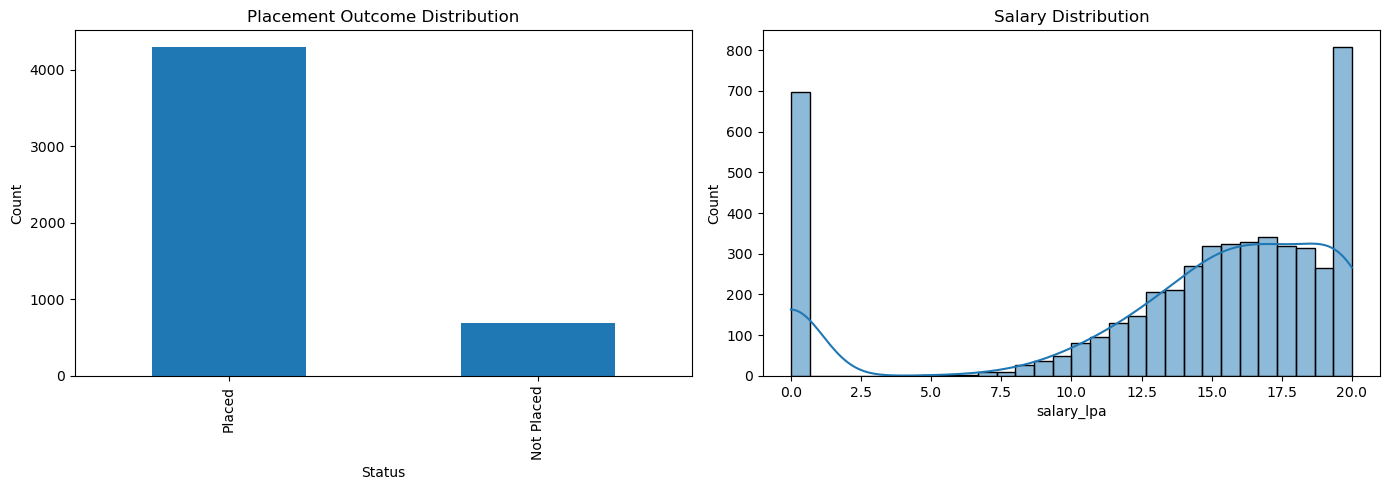

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data['placement_status'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Placement Outcome Distribution')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')

sns.histplot(data['salary_lpa'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Salary Distribution')

plt.tight_layout()
plt.show()


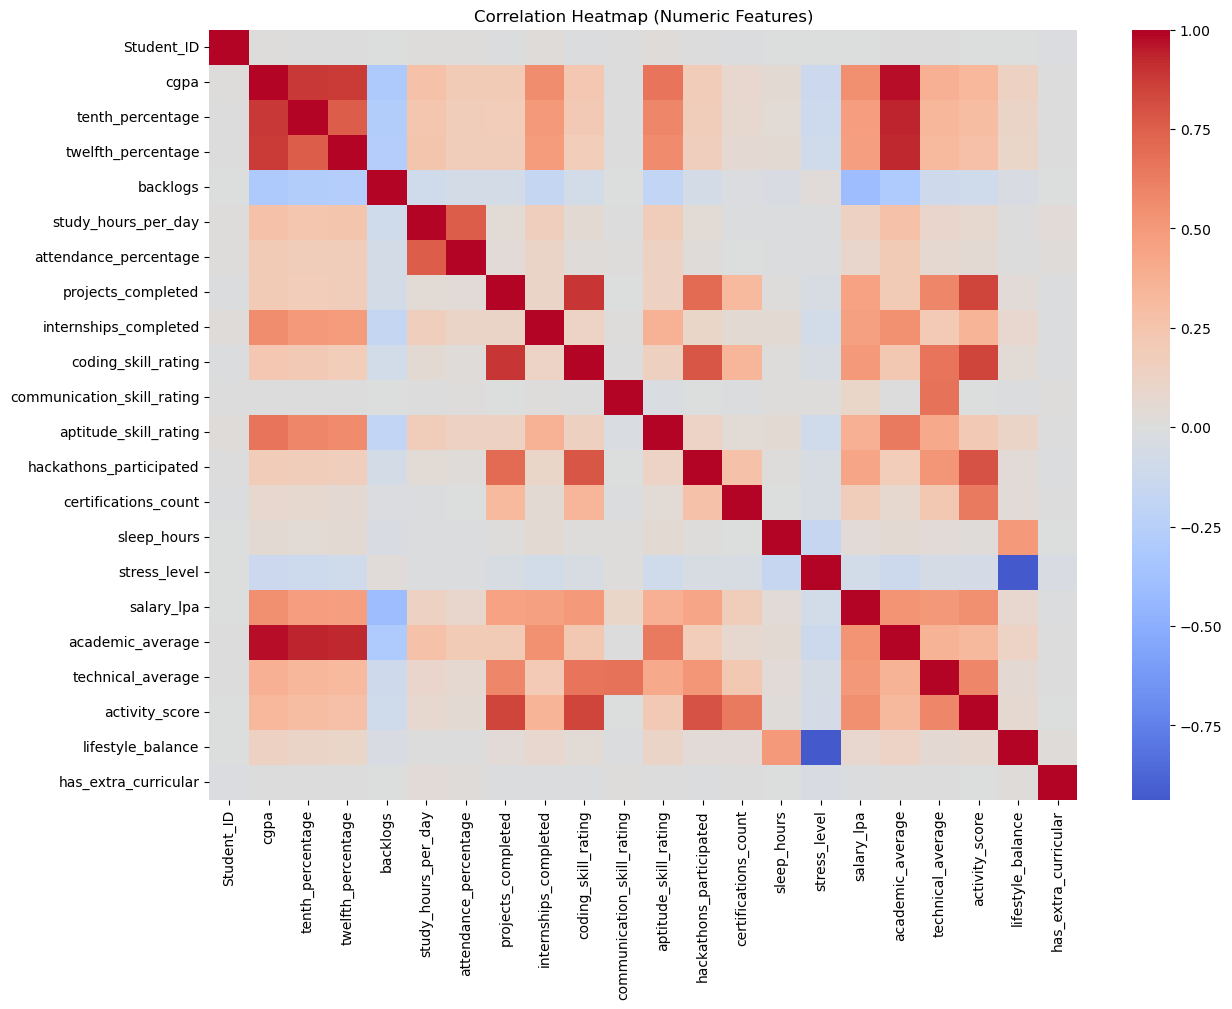

placement_binary           1.000000
salary_lpa                 0.895356
activity_score             0.354851
coding_skill_rating        0.343219
technical_average          0.333096
projects_completed         0.322796
cgpa                       0.315614
academic_average           0.301037
hackathons_participated    0.275848
tenth_percentage           0.269680
twelfth_percentage         0.268454
internships_completed      0.254189
Name: placement_binary, dtype: float64

In [6]:

# Correlation on numeric columns
num_cols = data.select_dtypes(include=np.number).columns
corr = data[num_cols].corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

placement_numeric = data.copy()
placement_numeric['placement_binary'] = (placement_numeric['placement_status'] == 'Placed').astype(int)
display(
    placement_numeric.select_dtypes(include=np.number).corr(numeric_only=True)['placement_binary']
    .sort_values(ascending=False)
    .head(12)
)



### Interpretasi singkat

Fitur yang biasanya paling kuat untuk penempatan dan salary pada data ini adalah:
- **cgpa**
- **tenth_percentage** dan **twelfth_percentage**
- **internships_completed**
- **coding_skill_rating**
- **projects_completed**
- **hackathons_participated**
- **aptitude_skill_rating**

Fitur gaya hidup seperti `sleep_hours` dan `stress_level` tetap dipertahankan karena bisa memberi sinyal tambahan, walau korelasinya biasanya lebih kecil.


## 3) Feature engineering

In [7]:

# Contoh feature engineering
feature_preview = data[['cgpa','tenth_percentage','twelfth_percentage',
                        'coding_skill_rating','communication_skill_rating','aptitude_skill_rating',
                        'projects_completed','internships_completed','hackathons_participated','certifications_count',
                        'sleep_hours','stress_level','academic_average','technical_average','activity_score','lifestyle_balance']]
feature_preview.head()


,cgpa,tenth_percentage,twelfth_percentage,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,projects_completed,internships_completed,hackathons_participated,certifications_count,sleep_hours,stress_level,academic_average,technical_average,activity_score,lifestyle_balance
0,8.74,74.0,75.0,4,2,5,7,3,4,5,6.5,8,78.800000,3.666667,19,-1.5
1,7.80,75.3,69.7,3,4,3,5,1,4,1,7.1,8,74.333333,3.333333,11,-0.9
2,6.95,62.8,68.3,5,1,4,8,2,6,3,6.1,2,66.866667,3.333333,19,4.1
3,7.46,57.9,51.4,3,1,4,6,2,2,2,7.3,7,61.300000,2.666667,12,0.3
4,6.86,61.3,73.5,2,5,3,3,3,2,1,6.0,7,67.800000,3.333333,9,-1.0


## 4) Train-test split (80:20)

In [8]:

# Classification dataset
X_cls = data.drop(columns=['Student_ID', 'placement_status', 'salary_lpa'])
y_cls = data['placement_status']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

# Regression dataset: only placed students
reg_data = data[data['placement_status'] == 'Placed'].copy()
X_reg = reg_data.drop(columns=['Student_ID', 'placement_status', 'salary_lpa'])
y_reg = reg_data['salary_lpa']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("Classification train/test:", X_train_c.shape, X_test_c.shape)
print("Regression train/test:", X_train_r.shape, X_test_r.shape)


Classification train/test: (4000, 27) (1000, 27)
Regression train/test: (3442, 27) (861, 27)


## 5) Modeling: Classification

In [9]:

num_cols_cls = X_cls.select_dtypes(include=np.number).columns.tolist()
cat_cols_cls = X_cls.select_dtypes(exclude=np.number).columns.tolist()

preprocessor_cls = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols_cls),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols_cls),
    ]
)

cls_models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced_subsample'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}

cls_results = []
for name, model in cls_models.items():
    pipe = Pipeline([('preprocess', preprocessor_cls), ('model', model)])
    pipe.fit(X_train_c, y_train_c)
    pred = pipe.predict(X_test_c)
    proba = pipe.predict_proba(X_test_c)[:, 1]
    cls_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_c, pred),
        'Precision': precision_score(y_test_c, pred, pos_label='Placed'),
        'Recall': recall_score(y_test_c, pred, pos_label='Placed'),
        'F1': f1_score(y_test_c, pred, pos_label='Placed'),
        'ROC AUC': roc_auc_score((y_test_c == 'Placed').astype(int), proba),
    })

cls_results_df = pd.DataFrame(cls_results).sort_values('F1', ascending=False)
display(cls_results_df)


,Model,Accuracy,Precision,Recall,F1,ROC AUC
1,Random Forest,0.888,0.895459,0.984901,0.938053,0.898336
2,Gradient Boosting,0.882,0.910497,0.957027,0.933182,0.908555
0,Logistic Regression,0.824,0.971114,0.819977,0.889169,0.910519



**Interpretasi klasifikasi**:  
F1-score dipilih sebagai metrik utama karena kelas `Not Placed` relatif minoritas. Pada eksperimen ini, model berbasis pohon biasanya unggul dalam menangkap interaksi non-linear antar fitur akademik, teknis, dan aktivitas.


## 6) Modeling: Regression

In [10]:

num_cols_reg = X_reg.select_dtypes(include=np.number).columns.tolist()
cat_cols_reg = X_reg.select_dtypes(exclude=np.number).columns.tolist()

preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols_reg),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols_reg),
    ]
)

reg_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=300, random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42),
}

reg_results = []
for name, model in reg_models.items():
    pipe = Pipeline([('preprocess', preprocessor_reg), ('model', model)])
    pipe.fit(X_train_r, y_train_r)
    pred = pipe.predict(X_test_r)
    reg_results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test_r, pred),
        'RMSE': mean_squared_error(y_test_r, pred) ** 0.5,
        'R2': r2_score(y_test_r, pred),
    })

reg_results_df = pd.DataFrame(reg_results).sort_values('R2', ascending=False)
display(reg_results_df)


,Model,MAE,RMSE,R2
2,Gradient Boosting Regressor,1.105719,1.398310,0.774468
0,Linear Regression,1.131559,1.407951,0.771347
1,Random Forest Regressor,1.172038,1.475696,0.748814



**Interpretasi regresi**:  
R2 digunakan untuk menilai seberapa baik variasi salary dijelaskan oleh fitur-fitur input. MAE dan RMSE membantu membaca besarnya error dalam satuan `lpa`.



## 8) Hasil eksperimen model

### Klasifikasi (`placement_status`)
| Model | Accuracy | Precision | Recall | F1 | ROC AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 0.824 | 0.971 | 0.820 | 0.889 | 0.911 |
| Random Forest | 0.888 | 0.895 | 0.985 | 0.938 | 0.898 |
| Gradient Boosting | 0.882 | 0.910 | 0.957 | 0.933 | 0.909 |

### Regresi (`salary_lpa`, hanya data *Placed*)
| Model | MAE | RMSE | R2 |
|---|---:|---:|---:|
| Linear Regression | 1.132 | 1.408 | 0.771 |
| Random Forest Regressor | 1.172 | 1.476 | 0.749 |
| Gradient Boosting Regressor | 1.106 | 1.398 | 0.774 |

**Model terbaik yang dipakai di deployment**:
- Klasifikasi: **Random Forest**
- Regresi: **Gradient Boosting Regressor**


## 7) Conclusion

Berdasarkan hasil eksperimen, ketiga model klasifikasi menunjukkan performa yang cukup baik dengan nilai akurasi di atas 0.82, yang mengindikasikan bahwa fitur-fitur yang digunakan sudah mampu merepresentasikan pola penempatan kerja mahasiswa dengan baik. Logistic Regression memiliki nilai precision tertinggi (0.971), namun recall yang relatif lebih rendah (0.820), yang menunjukkan bahwa model ini cenderung konservatif: sangat jarang salah dalam memprediksi mahasiswa yang berhasil ditempatkan, tetapi cukup sering melewatkan kandidat yang sebenarnya berpotensi. Di sisi lain, Random Forest menunjukkan performa terbaik secara keseluruhan dengan akurasi tertinggi (0.888), recall sangat tinggi (0.985), serta F1-score tertinggi (0.938). Hal ini berarti model mampu menangkap hampir seluruh mahasiswa yang berpotensi mendapatkan pekerjaan, sehingga sangat cocok digunakan dalam konteks screening atau rekomendasi. Gradient Boosting juga menunjukkan performa yang stabil dan seimbang, namun sedikit berada di bawah Random Forest. Selain itu, nilai ROC AUC yang tinggi pada semua model (sekitar 0.90) menunjukkan bahwa ketiga model memiliki kemampuan yang baik dalam membedakan kelas.

Untuk tugas regresi dalam memprediksi salary, ketiga model menunjukkan performa yang relatif mirip, yang mengindikasikan bahwa hubungan antara fitur dan gaji tidak terlalu kompleks. Linear Regression уже memberikan hasil yang cukup baik dengan R² sebesar 0.771, yang menunjukkan adanya hubungan linear yang cukup kuat. Namun, Gradient Boosting Regressor memberikan performa terbaik dengan nilai MAE (1.106) dan RMSE (1.398) terendah serta R² tertinggi (0.774), yang menandakan kemampuannya dalam menangkap pola non-linear yang mungkin tidak dapat ditangkap sepenuhnya oleh model linear. Sementara itu, Random Forest Regressor justru menunjukkan performa yang sedikit lebih rendah, kemungkinan karena karakteristik data yang tidak terlalu membutuhkan model berbasis pohon yang kompleks.

Berdasarkan keseluruhan hasil tersebut, model Random Forest dipilih untuk tugas klasifikasi karena mampu memberikan keseimbangan terbaik antara precision dan recall serta sangat efektif dalam meminimalkan kesalahan identifikasi mahasiswa yang berpotensi mendapatkan pekerjaan. Untuk tugas regresi, Gradient Boosting Regressor dipilih karena memberikan tingkat error paling rendah dan kemampuan generalisasi yang baik. Kombinasi kedua model ini dianggap optimal untuk diimplementasikan dalam sistem deployment karena mampu memberikan prediksi yang akurat dan stabil pada data baru.